Online E-Commerce Customer Conversion Analysis

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# data load
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape
# df.info()
# df.describe()

(12330, 18)

In [5]:
# checking missing value

df.isnull().sum()     #its already clean data from source

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [6]:
# prepare columns
df['Revenue'] = df['Revenue'].astype(int)
df['Weekend'] = df['Weekend'].astype(int)
# convert True False to 0,1

month_order = ['Jan','Feb','Mar','Apr','May','June','Jul','Aug','Sep','Oct','Nov','Dec']

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)


In [7]:
print("Total Sessions:", len(df))
print("Total Purchases:", df['Revenue'].sum())
print("Conversion Rate: {:.2f}%".format(df['Revenue'].mean()*100))
print("Average Bounce Rate:", df['BounceRates'].mean())

Total Sessions: 12330
Total Purchases: 1908
Conversion Rate: 15.47%
Average Bounce Rate: 0.02219138047072182


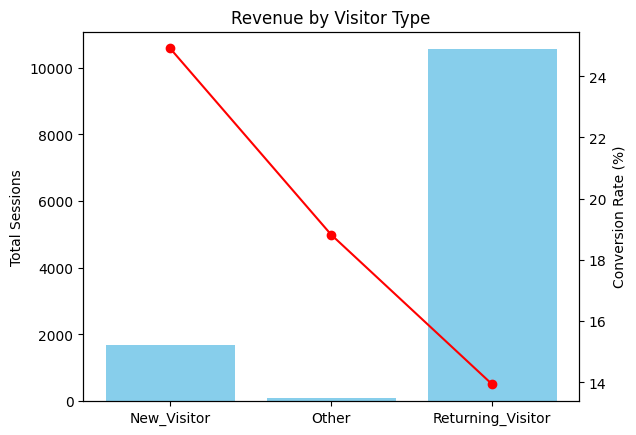

In [8]:
# Revenue by Visitor Type

visitor = df.groupby('VisitorType').agg(
    sessions=('Revenue','count'),
    purchases=('Revenue','sum'),
    conversion=('Revenue','mean')
)

visitor['conversion'] = visitor['conversion']*100

fig, ax1 = plt.subplots()

ax1.bar(visitor.index, visitor['sessions'], color='skyblue')
ax1.set_ylabel('Total Sessions')

ax2 = ax1.twinx()
ax2.plot(visitor.index, visitor['conversion'], color='red', marker='o')
ax2.set_ylabel('Conversion Rate (%)')

plt.title('Revenue by Visitor Type')
plt.xticks(rotation=0)
plt.show()

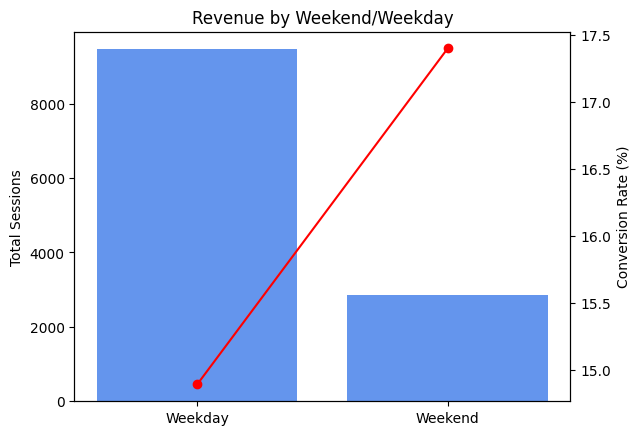

In [9]:
# WeekEnd Effect

week = df.groupby('Weekend').agg(
    sessions=('Revenue','count'),
    purchases=('Revenue','sum'),
    conversion=('Revenue','mean')
)
week['conversion']*=100

fig, ax1 = plt.subplots()

ax1.bar(['Weekday','Weekend'], week['sessions'], color='cornflowerblue')
ax1.set_ylabel('Total Sessions')

ax2 = ax1.twinx()
ax2.plot(['Weekday','Weekend'], week['conversion'], color='red', marker='o')
ax2.set_ylabel('Conversion Rate (%)')

plt.title('Revenue by Weekend/Weekday')
plt.show()

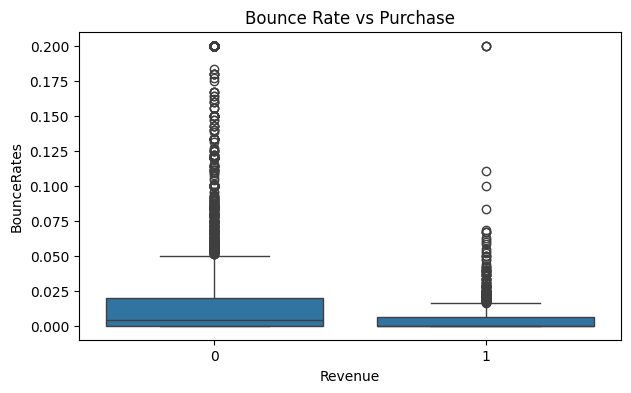

In [10]:
# Bounce Rate

plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title("Bounce Rate vs Purchase")
plt.show()

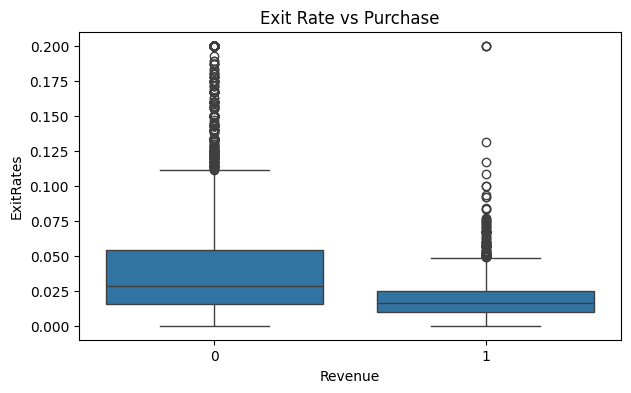

In [11]:
# Exit Rate

plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("Exit Rate vs Purchase")
plt.show()

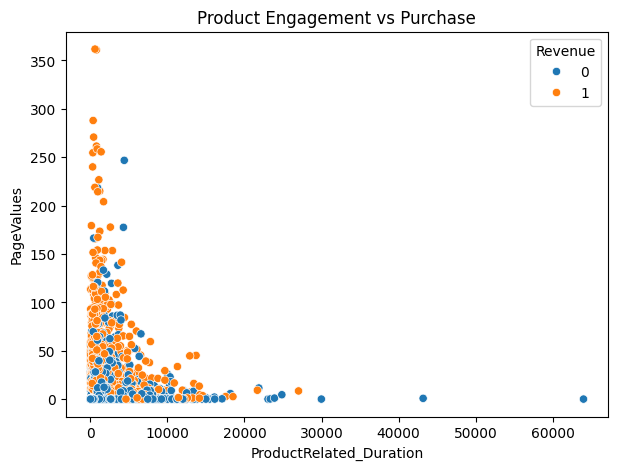

In [12]:
# Engagement Analysis

plt.figure(figsize=(7,5))
sns.scatterplot(x='ProductRelated_Duration', y='PageValues',
                hue='Revenue', data=df)
plt.title("Product Engagement vs Purchase")
plt.show()

/tmp/ipython-input-194/3195617287.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  month = df.groupby('Month').agg(


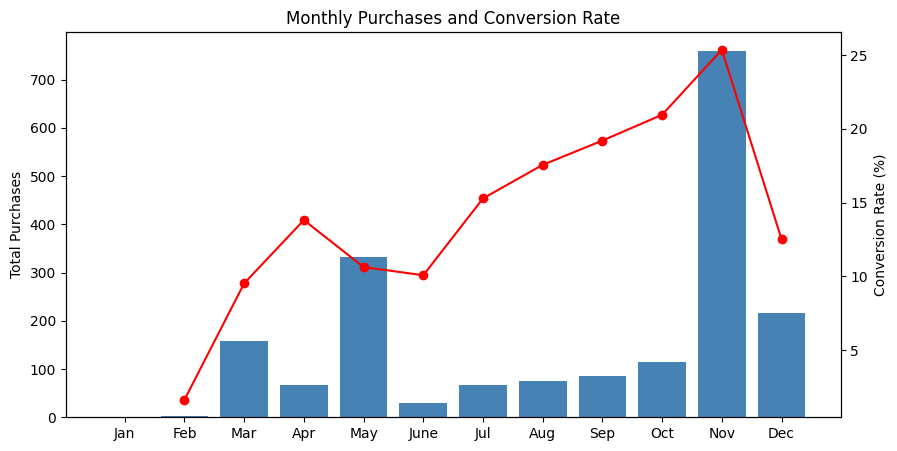

In [13]:
# Monthly Trend

month = df.groupby('Month').agg(
    purchases=('Revenue','sum'),
    conversion=('Revenue','mean')
)

month['conversion'] = month['conversion']*100

fig, ax1 = plt.subplots(figsize=(10,5))

# bar = purchases
ax1.bar(month.index, month['purchases'], color='steelblue')
ax1.set_ylabel('Total Purchases')

# line = conversion
ax2 = ax1.twinx()
ax2.plot(month.index, month['conversion'], color='red', marker='o')
ax2.set_ylabel('Conversion Rate (%)')

plt.title('Monthly Purchases and Conversion Rate')
plt.xticks(rotation=45)
plt.show()

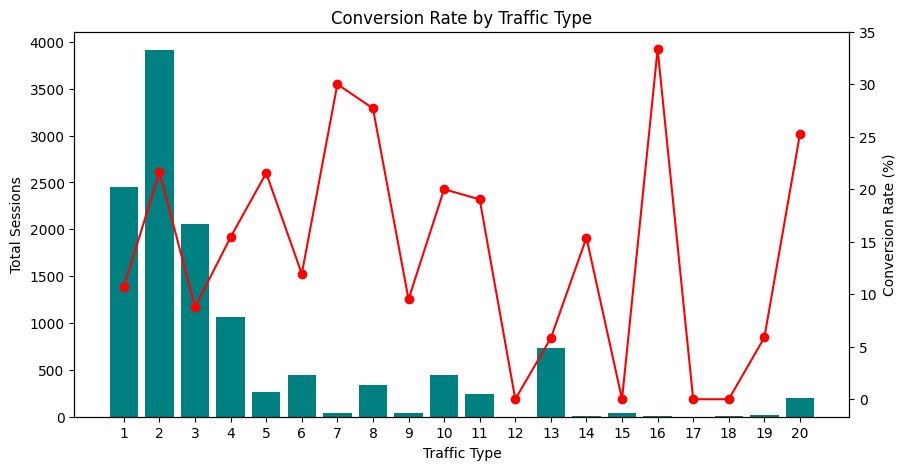

In [14]:
# Conversion rate by Traffic Type


traffic = df.groupby('TrafficType').agg(
    sessions=('Revenue','count'),
    conversion=('Revenue','mean')
)

traffic['conversion'] *= 100

fig, ax1 = plt.subplots(figsize=(10,5))

# bar chart (sessions)
ax1.bar(traffic.index.astype(str), traffic['sessions'], color='teal')
ax1.set_ylabel('Total Sessions')
ax1.set_xlabel('Traffic Type')

# line chart (conversion)
ax2 = ax1.twinx()
ax2.plot(traffic.index.astype(str), traffic['conversion'], color='red', marker='o')
ax2.set_ylabel('Conversion Rate (%)')

plt.title('Conversion Rate by Traffic Type')
plt.xticks(rotation=0)
plt.show()

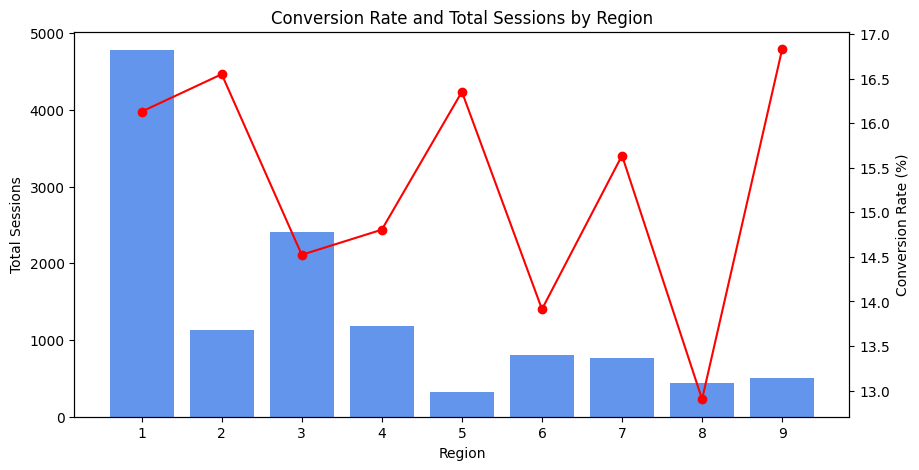

In [15]:
# Region wise Conversion Rate

region = df.groupby('Region').agg(
    sessions=('Revenue','count'),
    conversion=('Revenue','mean')
)

region['conversion'] = region['conversion'] * 100

fig, ax1 = plt.subplots(figsize=(10,5))

# Bar chart → total sessions
ax1.bar(region.index.astype(str), region['sessions'], color='cornflowerblue')
ax1.set_ylabel('Total Sessions')
ax1.set_xlabel('Region')

# Line chart → conversion rate
ax2 = ax1.twinx()
ax2.plot(region.index.astype(str), region['conversion'], color='red', marker='o')
ax2.set_ylabel('Conversion Rate (%)')

plt.title('Conversion Rate and Total Sessions by Region')
plt.xticks(rotation=0)
plt.show()

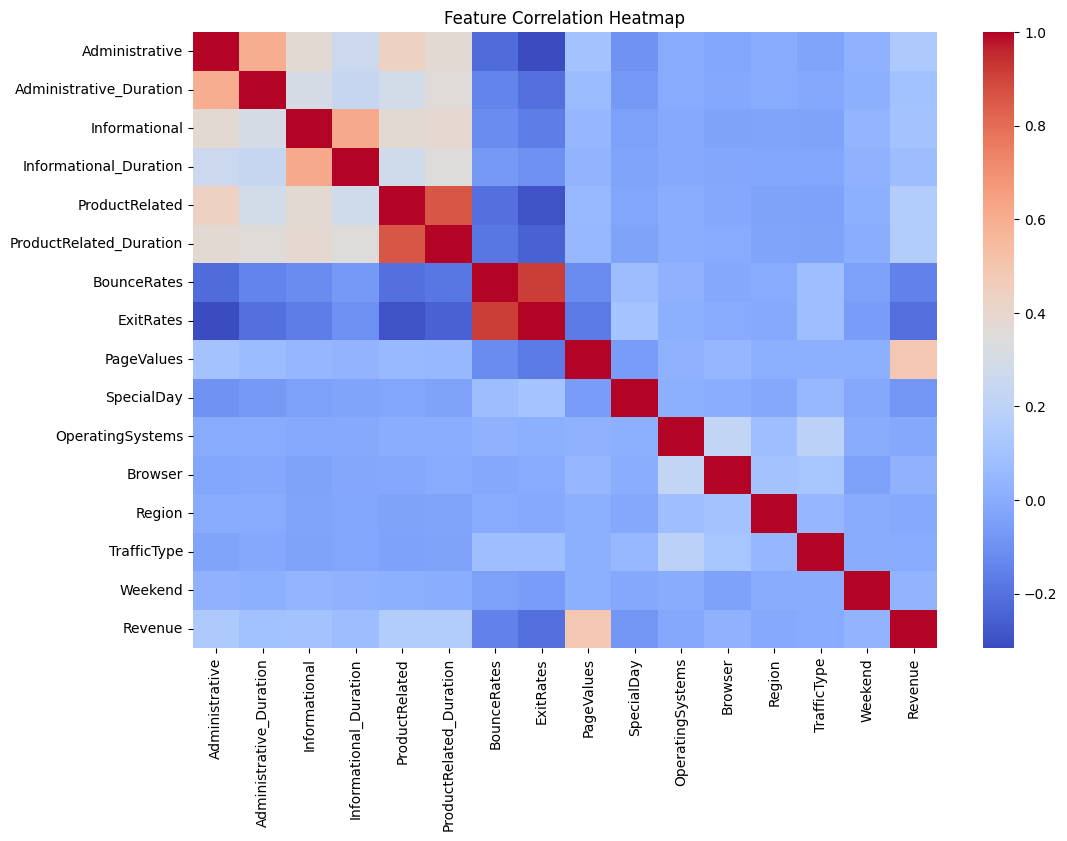

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()